![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# TEXT MINING FINAL PROJECT

**Abstract**

Online reviews play a crucial role in shaping consumer decisions in digital marketplaces such as Airbnb. While numerical ratings provide a simple summary of guest satisfaction, written reviews contain richer information about the aspects of a stay that guests value most or find problematic. This project applies text mining and natural language processing techniques to analyze Airbnb reviews and identify linguistic patterns associated with positive and negative guest experiences.

Using review data obtained from the Inside Airbnb dataset for Barcelona, we translated all the reviews to English. After that, we first perform exploratory data analysis to understand the structure of the dataset and the general characteristics of the reviews. The text is then preprocessed through standard natural language processing steps including lowercasing, punctuation removal, and stopword filtering in order to construct a clean textual corpus suitable for analysis.

We then apply term-frequency based methods, such as TF-IDF, to identify the most informative words that characterize different types of reviews. In addition, topic modeling techniques are used to uncover common themes discussed by guests, such as location, cleanliness, and communication with hosts. Finally, a supervised classification model is trained to evaluate whether the textual content of reviews can be used to predict whether a guest experience was positive or negative.

Through this analysis, the project demonstrates how text mining techniques can extract meaningful insights from unstructured review data and provide a systematic understanding of the factors that shape guest satisfaction in the Airbnb platform.


# 1. Import libraries and read the csv

In [1]:
import pandas as pd

#this is loading training dataset
filename ='https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/reviews_translated.csv'

# loading the training data
data_train = pd.read_csv(filename, sep=',', encoding='utf-8')
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019270 entries, 0 to 1019269
Data columns (total 7 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   listing_id           1019270 non-null  int64 
 1   id                   1019270 non-null  int64 
 2   date                 1019270 non-null  object
 3   reviewer_id          1019270 non-null  int64 
 4   reviewer_name        1019266 non-null  object
 5   comments             1019160 non-null  object
 6   Reviews_Translation  1015329 non-null  object
dtypes: int64(3), object(4)
memory usage: 54.4+ MB


# 2. Exploratory Data Analysis

Before applying text mining techniques, we perform an exploratory analysis of the dataset in order to better understand its structure and general characteristics. Exploratory Data Analysis (EDA) helps identify potential issues in the data, such as missing values, extremely short or long reviews, and irregularities in the textual content.

In this stage, we focus on examining the basic properties of the review corpus. This includes inspecting the number of observations, exploring examples of the review text, and analyzing the distribution of review lengths. Studying the length of reviews can provide useful insights into how users typically describe their experiences on the platform and whether the dataset contains outliers that may affect the analysis.

Additionally, we analyze the most frequent words appearing in the corpus. This provides an initial overview of the dominant vocabulary used by guests when describing their stays. Such insights can highlight commonly discussed aspects of Airbnb experiences, such as location, cleanliness, communication with the host, or the overall quality of the accommodation.

The results of this exploratory analysis help guide the preprocessing and modeling steps that follow, ensuring that the text mining techniques are applied to a well-understood and properly prepared dataset.


In [2]:
#Reviews are in different languages, we need to translate them into english to work with them
raw_comments = data_train['comments'].head()
raw_comments.head()

0    Excelente lugar y buena ubicación, repetiría e...
1              Very good host and always ready to help
2    Excellent place to stay and great location. Re...
3    Easy and quick communication with the host, gr...
4    Beautiful apartment in a very great neighbourh...
Name: comments, dtype: object

The translations for each review appears in Reviews_Translation column.

In [3]:
#We already did that work, and the translations for each review appears in Reviews_Translation column
comments = data_train['Reviews_Translation']
comments.head()
print(len(comments))

1019270


In [4]:
#DATA EXPLORATION
#Length of our dataset
print("Number of reviews:", len(comments))

#Check and remove missing values
print("Number of missing values:", comments.isnull().sum())
data_train = data_train.dropna(subset=['Reviews_Translation'])
data_train = data_train.drop(68051)

comments = data_train['Reviews_Translation']

review_length = comments.apply(lambda x: len(x.split()))
review_length.describe()

Number of reviews: 1019270
Number of missing values: 3941


count    1.015328e+06
mean     3.991268e+01
std      4.138686e+01
min      0.000000e+00
25%      1.200000e+01
50%      2.800000e+01
75%      5.400000e+01
max      1.000000e+03
Name: Reviews_Translation, dtype: float64

Text(0.5, 1.0, 'Distribution of Airbnb Review Lengths')

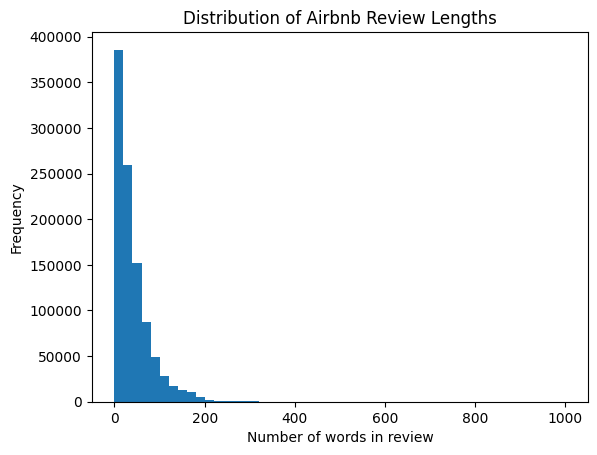

In [5]:
import matplotlib.pyplot as plt

plt.hist(review_length, bins=50)
plt.xlabel("Number of words in review")
plt.ylabel("Frequency")
plt.title("Distribution of Airbnb Review Lengths")

### Plot to get the word frequency distribution (with stopwords)
-Can`t this be done with CountVectorizer?

In [6]:
import re

def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    return text

clean_comments = comments.apply(clean_text)

In [7]:
from collections import Counter

all_words = []

for review in clean_comments:

    words = review.split()
    all_words.extend(words)

In [8]:
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

print(common_words)

[('the', 2215157), ('and', 1755603), ('a', 1078571), ('to', 1054055), ('was', 838808), ('is', 799933), ('very', 722971), ('in', 701493), ('we', 528351), ('apartment', 508315), ('of', 490278), ('for', 467147), ('great', 410955), ('it', 394968), ('with', 380464), ('location', 351577), ('stay', 333572), ('i', 304292), ('you', 298144), ('place', 249497)]


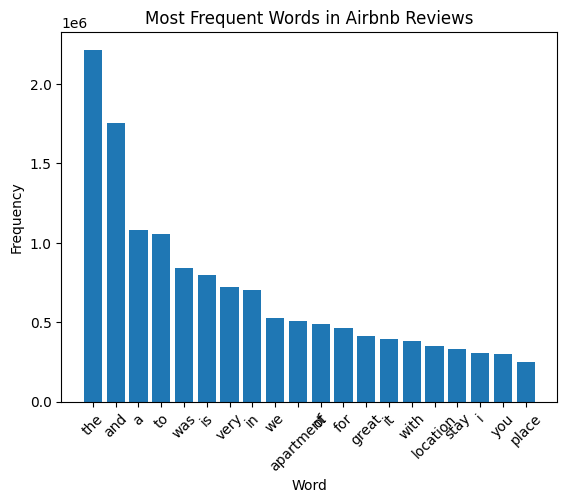

In [9]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)

plt.title("Most Frequent Words in Airbnb Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

### Text Preprocessing

Before applying text mining techniques, the raw textual data must be cleaned and standardized. Raw reviews often contain punctuation, capital letters, and common words that do not contribute meaningful information for the analysis. Therefore, a series of preprocessing steps are applied to transform the raw text into a structured textual corpus suitable for analysis.

The preprocessing pipeline typically includes converting all text to lowercase, removing punctuation and non-alphabetic characters, and filtering out common stopwords such as “the”, “and”, or “is”. These steps help reduce noise in the dataset and focus the analysis on informative words that better capture the content of the reviews.

After preprocessing, the cleaned text is used to construct a document-term representation of the corpus, which allows us to apply techniques such as TF-IDF weighting and supervised classification models in the later stages of the analysis.


In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.corpus import stopwords
%pip install spacy
import spacy
from matplotlib import pyplot as plt
from tqdm import tqdm

# Function to download NLTK resources
def download_nltk_resources():
    required_resources = ['wordnet', 'stopwords', 'punkt']
    for resource in required_resources:
        try:
            nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

# Load spaCy model; if missing, install it in the current Jupyter kernel environment.
try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download

    print("Installing spaCy model 'en_core_web_sm' for this environment...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

# Enable tqdm for pandas
tqdm.pandas()

# Initialize stemmers and lemmatizer
porter = SnowballStemmer("english")
lmtzr = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ecasc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
#General functions for the preprocessing
"""
This module provides helper functions for text preprocessing.
Each function applies punctuation removal and stopword removal, and then one of three options:
    0: Lowercasing only.
    1: Lowercasing plus stemming.
    2: Lemmatizing (using spaCy; original casing is preserved).

The functions return a string of tokens separated by spaces.
"""

def preprocess_lower(text):
    """
    Preprocess text by:
       - Converting to lowercase.
       - Removing punctuation.
       - Tokenizing.
       - Removing stopwords.

    Returns:
        str: A string of filtered tokens separated by spaces.
    """
    text_lower = text.lower()
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)
    tokens = word_tokenize(text_no_punct)
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(filtered_tokens)

def preprocess_stem(text):
    """
    Preprocess text by performing all steps in preprocess_lower() and then applying stemming.

    Returns:
        str: A string of stemmed tokens separated by spaces.
    """
    tokens = preprocess_lower(text).split()
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

def preprocess_lemma(text):
    """
    Preprocess text by:
       - Removing punctuation and stopwords using spaCy's token attributes.
       - Lemmatizing the text.
       - (Note: This function does NOT lowercase the text.)

    Returns:
        str: A string of lemmatized tokens separated by spaces.
    """
    doc = sp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']
    return " ".join(lemmatized_tokens)

def tokenize(text, mode=0):
    """
    General tokenize function. Always applies punctuation and stopword removal and then:

      mode = 0: Applies lowercasing.
      mode = 1: Applies lowercasing and stemming.
      mode = 2: Applies lemmatization (without lowercasing the original text).

    Args:
        text (str): The input text to be processed.
        mode (int): Processing mode (0 for lowercasing; 1 for stemming; 2 for lemmatizing).

    Returns:
        str: A string of processed tokens separated by spaces.

    Raises:
        ValueError: If an invalid mode is provided.
    """
    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")


In [12]:
"""#1. Remove punctuation and digits and remove stopwords, and lemmatizing
mod = 2

# Pre-process the text column with progress tracking
try:
    preprocessed_comments = comments.astype(str).progress_apply(lambda row: tokenize(row, mod))
    print("Done processing text.")
except Exception as e:
    print(f"Error processing text column: {e}")
    raise RuntimeError(f"Error processing text column: {e}") from e

print(preprocessed_comments.head())"""

'#1. Remove punctuation and digits and remove stopwords, and lemmatizing\nmod = 2\n\n# Pre-process the text column with progress tracking\ntry:\n    preprocessed_comments = comments.astype(str).progress_apply(lambda row: tokenize(row, mod))\n    print("Done processing text.")\nexcept Exception as e:\n    print(f"Error processing text column: {e}")\n    raise RuntimeError(f"Error processing text column: {e}") from e\n\nprint(preprocessed_comments.head())'

#### We use our already preprocessed data to be faster computing the methodology

In [13]:
#preprocessed_comments = pd.read_csv('preprocessed_comments.csv', sep=',', encoding='utf-8')
preprocessed_comments = pd.read_csv('https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/preprocessed_comments.csv', sep=',', encoding='utf-8')
preprocessed_comments.info()

#We remove <br>
preprocessed_comments['Reviews_Translation'] = preprocessed_comments['Reviews_Translation'].str.replace(r'<br\s*/?>', ' ', regex=True)
preprocessed_comments['Reviews_Translation'].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100415 entries, 0 to 100414
Data columns (total 1 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Reviews_Translation  100172 non-null  object
dtypes: object(1)
memory usage: 784.6+ KB


0    excellent place good location repeat place hes...
1                                 good host ready help
2        excellent place stay great location recommend
3    easy quick communication host great location s...
4    beautiful apartment great neighbourhood mainta...
Name: Reviews_Translation, dtype: object

In [14]:
preprocessed_comments['Reviews_Translation'] = preprocessed_comments['Reviews_Translation'].str.replace('<br>', '', regex=False)
preprocessed_comments['Reviews_Translation'] = preprocessed_comments['Reviews_Translation'].str.replace('br', '', regex=False)
print("Preprocessed comments after removing '<br>':")
print(preprocessed_comments.head())

Preprocessed comments after removing '<br>':
                                 Reviews_Translation
0  excellent place good location repeat place hes...
1                               good host ready help
2      excellent place stay great location recommend
3  easy quick communication host great location s...
4  beautiful apartment great neighbourhood mainta...


### Show most frequent words/terms after preprocessing

-Can't this be done with CountVectorizer?

In [15]:
from collections import Counter

all_words = []

# Filter out NaN values before iterating
for review in preprocessed_comments['Reviews_Translation'].dropna():
    words = review.split()
    all_words.extend(words)

In [16]:
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

print(common_words)

[('apartment', 63340), ('great', 41987), ('stay', 40259), ('<', 35109), ('location', 31773), ('place', 28099), ('Barcelona', 24092), ('good', 23905), ('host', 22004), ('clean', 21886), ('recommend', 21029), ('nice', 19873), ('close', 15042), ('walk', 14597), ('metro', 13892), ('perfect', 13853), ('need', 13610), ('comfortable', 13299), ('restaurant', 11965), ('time', 11819)]


Text(0, 0.5, 'Frequency')

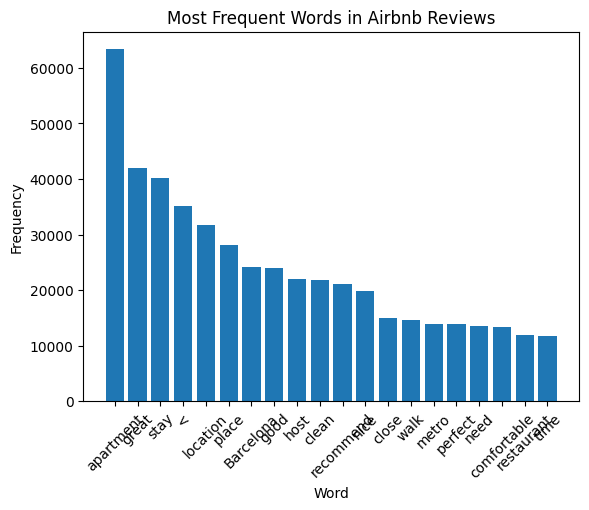

In [17]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)

plt.title("Most Frequent Words in Airbnb Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")

# TF_IDF Implementation:
Term Frequency–Inverse Document Frequency (TF-IDF) will be used to identify words that are most important for distinguishing positive and negative reviews.
Separate TF-IDF scores will be analyzed for positive and negative reviews.
This helps identify the most characteristic words in each group.




In [18]:

# TF_IDF

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

text_for_tfidf = preprocessed_comments['Reviews_Translation'].fillna('').astype(str)
text_for_tfidf = text_for_tfidf[text_for_tfidf.str.strip().ne('')]

# Save valid indices so X and y match
valid_index = text_for_tfidf.index

if text_for_tfidf.empty:
    raise ValueError('No preprocessed text found for TF-IDF.')

vectorizer_min_df = globals().get('vectorizer_min_df', 3)
vectorizer_max_df = globals().get('vectorizer_max_df', 0.75)
vectorizer_ngram_range = globals().get('vectorizer_ngram_range', (1, 3))

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=vectorizer_ngram_range,
    min_df=3,
    max_df=vectorizer_max_df,
    lowercase=False
)

X_tfidf = tfidf_vectorizer.fit_transform(text_for_tfidf)

terms = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()

df_tfidf_terms = pd.DataFrame({
    'term': terms,
    'tfidf': tfidf_scores
})

df_tfidf_terms = df_tfidf_terms.sort_values(by='tfidf', ascending=False).reset_index(drop=True)

print("TF-IDF matrix shape:", X_tfidf.shape)


TF-IDF matrix shape: (100172, 170156)


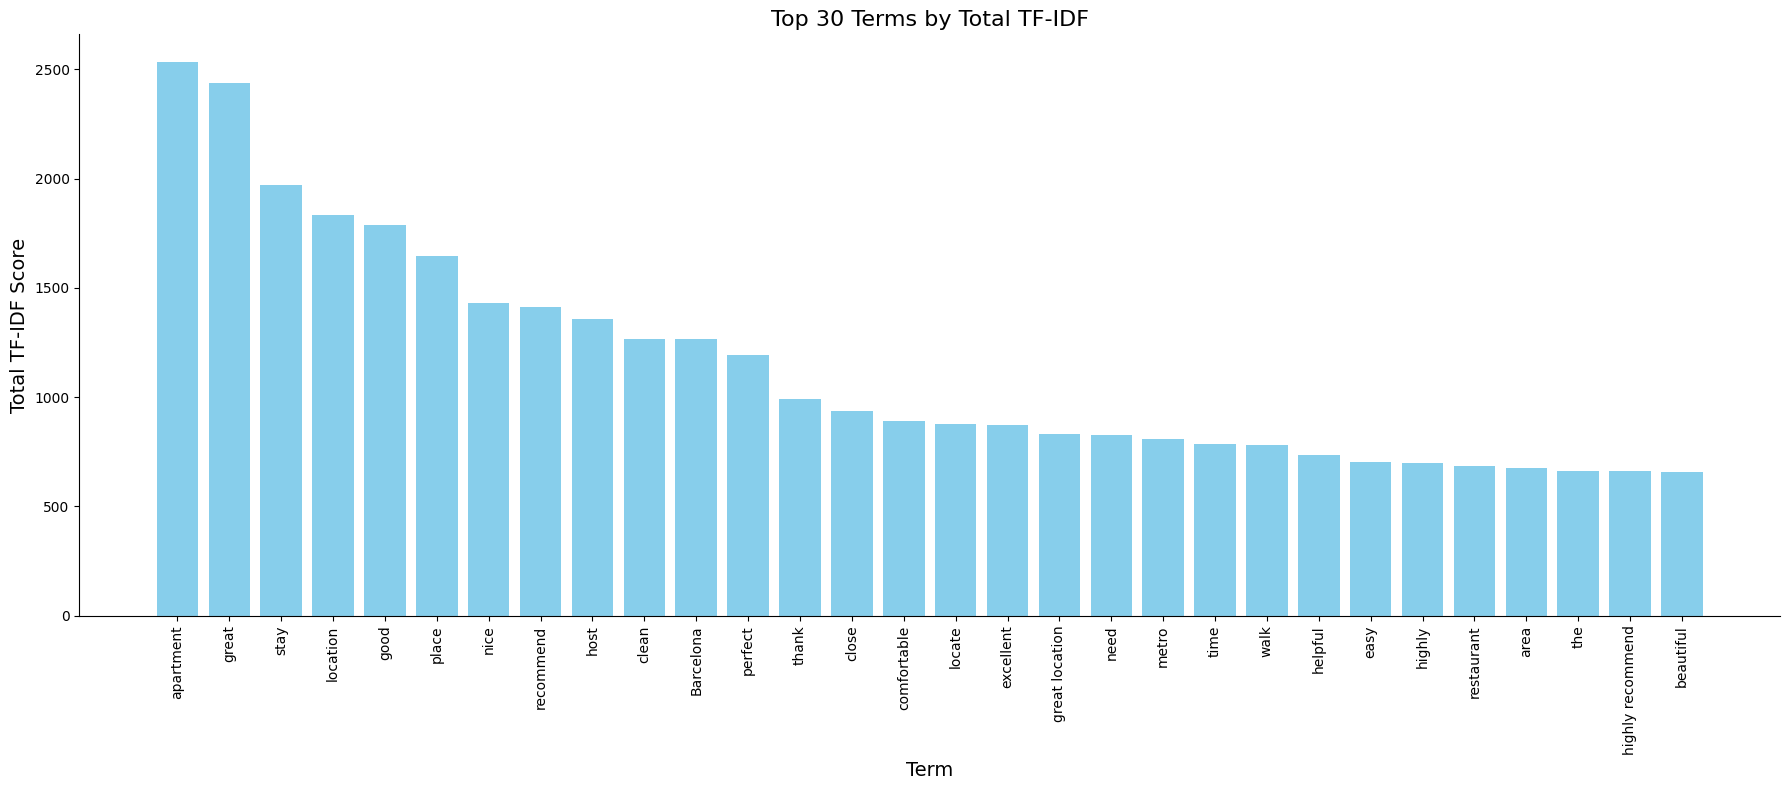

In [19]:
# Plot the top TF-IDF terms using total TF-IDF weight.
top_n = min(30, df_tfidf_terms.shape[0])
plot_data = df_tfidf_terms.head(top_n).copy()

plt.figure(figsize=(18, 8))
plt.bar(plot_data['term'], plot_data['tfidf'], color='skyblue')

plt.xlabel('Term', fontsize=14)
plt.ylabel('Total TF-IDF Score', fontsize=14)
plt.title(f'Top {top_n} Terms by Total TF-IDF', fontsize=16)
plt.xticks(rotation=90, fontsize=10)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Topic Modeling (LDA)

LDA was implemented in four steps. First, reviews were converted into a document-term matrix using `CountVectorizer` with custom stopwords and frequency thresholds (`min_df` and `max_df`) to keep informative tokens. Second, this matrix was transformed into a Gensim corpus and dictionary format required by the LDA algorithm. Third, multiple models were trained with different numbers of topics, and coherence (`c_v`) was used to select the best configuration. Finally, the selected model (5 topics) was retrained and interpreted using top words per topic, document-level topic distributions, and topic word clouds.


In [20]:
#LDA
preprocessed = preprocessed_comments['Reviews_Translation']
preprocessed = preprocessed.str.replace('<br>', '', regex=False)
preprocessed = preprocessed.str.replace('br', '', regex=False)
print("Preprocessed comments after removing '<br>':")
print(preprocessed.head())

Preprocessed comments after removing '<br>':
0    excellent place good location repeat place hes...
1                                 good host ready help
2        excellent place stay great location recommend
3    easy quick communication host great location s...
4    beautiful apartment great neighbourhood mainta...
Name: Reviews_Translation, dtype: object


In [21]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update(['de','el','la','apartment'])

# Using CountVectorizer for LDA input, with adjusted max_df and custom stopwords
# We'll use the preprocessed Series directly, after dropping NaN values.
count_vectorizer = CountVectorizer(stop_words=list(custom_stopwords), max_df=0.8, min_df=2)
count_data = count_vectorizer.fit_transform(preprocessed.dropna())

In [22]:
import scipy
%pip install gensim
from gensim import corpora, models
from gensim.matutils import Sparse2Corpus
from scipy.sparse import csr_matrix

from gensim import corpora, models
from gensim.matutils import Sparse2Corpus
from scipy.sparse import csr_matrix

cv = CountVectorizer(ngram_range=(1,3), lowercase=False, min_df=0.001, max_df=0.3)

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Convert to Gensim format
dtm_sparse = csr_matrix(count_data)
corpus_gensim = Sparse2Corpus(dtm_sparse, documents_columns=False)

# Create Gensim dictionary using the vocabulary from the fitted count_vectorizer
vocabulary_gensim = {val: key for key, val in count_vectorizer.vocabulary_.items()}
dictionary = corpora.Dictionary()
dictionary.id2token = vocabulary_gensim
dictionary.token2id = count_vectorizer.vocabulary_

We applied a coherence score to get the optimal number of topics:

Evaluating optimal number of topics...
(This will take some time as it trains multiple LDA models. Passes are reduced to 2 for speed.)
Training model with 3 topics...
  -> Coherence Value: 0.5480
Training model with 4 topics...
  -> Coherence Value: 0.5396
Training model with 5 topics...
  -> Coherence Value: 0.5468
Training model with 6 topics...
  -> Coherence Value: 0.5387
Training model with 7 topics...
  -> Coherence Value: 0.5361
Training model with 8 topics...
  -> Coherence Value: 0.5342
Training model with 9 topics...
  -> Coherence Value: 0.5403
Training model with 10 topics...
  -> Coherence Value: 0.5405
Training model with 11 topics...
  -> Coherence Value: 0.5346
Training model with 12 topics...
  -> Coherence Value: 0.5359
Training model with 13 topics...
  -> Coherence Value: 0.5269
Training model with 14 topics...
  -> Coherence Value: 0.5358
Training model with 15 topics...
  -> Coherence Value: 0.5370


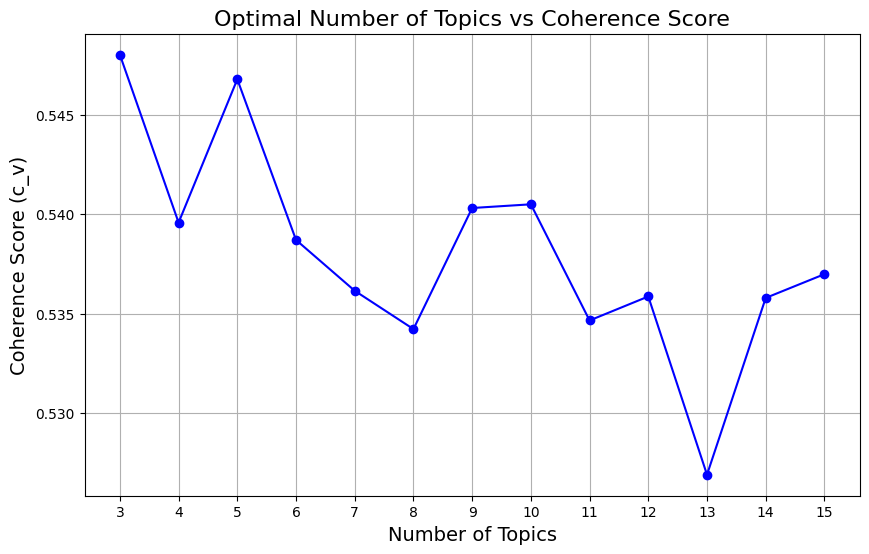

In [24]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel
from gensim import models, corpora
from gensim.matutils import Sparse2Corpus
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
import os
import pandas as pd

# Ensure preprocessed_comments is available in memory
if 'preprocessed_comments' not in globals():
    print("Loading preprocessed_comments from GitHub...")
    preprocessed_comments = pd.read_csv('https://media.githubusercontent.com/media/ElvisCasco/Text_Mining_Project/refs/heads/main/preprocessed_comments.csv', sep=',', encoding='utf-8')

preprocessed_text = preprocessed_comments['Reviews_Translation'].dropna()

# Recreate corpus and dictionary if they are missing
if 'corpus_gensim' not in globals() or 'dictionary' not in globals():
    print("Recreating corpus and dictionary...")
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

    custom_stopwords = set(stopwords.words('english'))
    custom_stopwords.update(['de','el','la','apartment'])

    count_vectorizer = CountVectorizer(stop_words=list(custom_stopwords), max_df=0.8, min_df=2)
    count_data = count_vectorizer.fit_transform(preprocessed_text)

    dtm_sparse = csr_matrix(count_data)
    corpus_gensim = Sparse2Corpus(dtm_sparse, documents_columns=False)

    vocabulary_gensim = {val: key for key, val in count_vectorizer.vocabulary_.items()}
    dictionary = corpora.Dictionary()
    dictionary.id2token = vocabulary_gensim
    dictionary.token2id = count_vectorizer.vocabulary_

# Define range to evaluate
start_topics = 3
limit_topics = 16  # 16 is exclusive, so it goes up to 15
step = 1

coherence_values = []
model_list = []

print("Evaluating optimal number of topics...")
print("(This will take some time as it trains multiple LDA models. Passes are reduced to 2 for speed.)")

workers = max(1, os.cpu_count() - 1)

# We need the tokenized texts for the 'c_v' coherence metric
texts = [str(doc).split() for doc in preprocessed_text]

for num_topics in range(start_topics, limit_topics, step):
    print(f"Training model with {num_topics} topics...")
    # Build LDA model (fewer passes to speed up evaluation)
    model = models.LdaMulticore(
        corpus=corpus_gensim,
        num_topics=num_topics,
        id2word=dictionary,
        passes=2,
        workers=workers,
        random_state=42
    )
    model_list.append(model)

    # Compute Coherence Score
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    score = coherencemodel.get_coherence()
    coherence_values.append(score)
    print(f"  -> Coherence Value: {score:.4f}")

# Plot the results
x = range(start_topics, limit_topics, step)
plt.figure(figsize=(10, 6))
plt.plot(x, coherence_values, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Topics", fontsize=14)
plt.ylabel("Coherence Score (c_v)", fontsize=14)
plt.title("Optimal Number of Topics vs Coherence Score", fontsize=16)
plt.xticks(x)
plt.grid(True)
plt.show()

We select 5 topics as the optimal number. We can describe the top 10 words for each topic:

In [25]:
import os

num_topics = 5

print(f"Running LDA with {num_topics} topics...")
print("(Optimized for speed using LdaMulticore...)")

# Get available CPU cores (leave 1 free for the system)
workers = max(1, os.cpu_count() - 1)

# Build LDA model optimized for speed
lda_model = models.LdaMulticore(
    corpus=corpus_gensim,
    id2word=dictionary,
    num_topics=num_topics,
    passes=10,          # Reduced from 20. 5-10 is usually enough for a large corpus
    chunksize=10000,    # Process more documents in memory per batch
    workers=workers,    # Use multiple CPU cores
    random_state=42
)

print("\n✅ LDA model trained!")

# Display topics
print("\n=== LDA Topics (Top 10 words each) ===")
topics = lda_model.print_topics(num_words=10)
for idx, topic in topics:
    print(f"\nTopic {idx}: {topic}")

Running LDA with 5 topics...
(Optimized for speed using LdaMulticore...)

✅ LDA model trained!

=== LDA Topics (Top 10 words each) ===

Topic 0: 0.024*"walk" + 0.017*"minute" + 0.014*"location" + 0.013*"great" + 0.012*"metro" + 0.010*"stay" + 0.010*"barcelona" + 0.010*"check" + 0.010*"place" + 0.009*"close"

Topic 1: 0.037*"great" + 0.021*"location" + 0.020*"host" + 0.018*"stay" + 0.016*"place" + 0.014*"nice" + 0.014*"good" + 0.013*"clean" + 0.012*"room" + 0.010*"time"

Topic 2: 0.018*"good" + 0.015*"clean" + 0.014*"nice" + 0.013*"stay" + 0.011*"location" + 0.009*"great" + 0.009*"host" + 0.009*"locate" + 0.007*"place" + 0.007*"recommend"

Topic 3: 0.019*"place" + 0.016*"metro" + 0.016*"stay" + 0.014*"barcelona" + 0.013*"nice" + 0.012*"close" + 0.011*"restaurant" + 0.011*"good" + 0.010*"easy" + 0.010*"comfortable"

Topic 4: 0.041*"stay" + 0.034*"great" + 0.027*"location" + 0.026*"barcelona" + 0.024*"recommend" + 0.020*"place" + 0.017*"perfect" + 0.016*"thank" + 0.014*"host" + 0.014*"goo

In [26]:
# Verify Topic Distributions
# Verify topic shares sum to 1

# Get topic distributions for each document
# lda_model.get_document_topics returns a list of lists, where each inner list
# contains (topic_id, probability) pairs for a document.
document_topics = lda_model.get_document_topics(corpus_gensim, minimum_probability=0.0)

# Create a list of dictionaries, one for each document's topic probabilities
# The dictionary keys will be 'topic_0', 'topic_1', etc.
topic_distributions = []
for doc_topics in document_topics:
    doc_topic_dict = {f'topic_{topic_id}': prob for topic_id, prob in doc_topics}
    topic_distributions.append(doc_topic_dict)

# Convert the list of dictionaries to a DataFrame
df_topic_distributions = pd.DataFrame(topic_distributions).fillna(0)

# Concatenate with the original corpus_data. Reset index to ensure alignment.
# Note: Assuming corpus_data has an index that corresponds to the order of documents in corpus_gensim.
# If corpus_data has been reindexed or filtered, careful alignment is needed.
corpus_data = pd.concat([preprocessed_text.reset_index(drop=True).to_frame(name='Reviews_Translation'), df_topic_distributions], axis=1)

# Now, verify topic shares sum to 1
corpus_data['topic_sum'] = corpus_data[[f'topic_{i}' for i in range(num_topics)]].sum(axis=1)
corpus_data['sum_is_1'] = np.isclose(corpus_data['topic_sum'], 1.0)

summary = corpus_data['sum_is_1'].value_counts()
print("=== Topic Distribution Validation ===")
print(summary)
print(f"\n✅ All distributions valid: {summary.get(True, 0) == len(corpus_data)}")

=== Topic Distribution Validation ===
sum_is_1
True    100172
Name: count, dtype: int64

✅ All distributions valid: True


Using wordcloud allows us to name the topics by using the most important words in each topic as reference:

Note: you may need to restart the kernel to use updated packages.


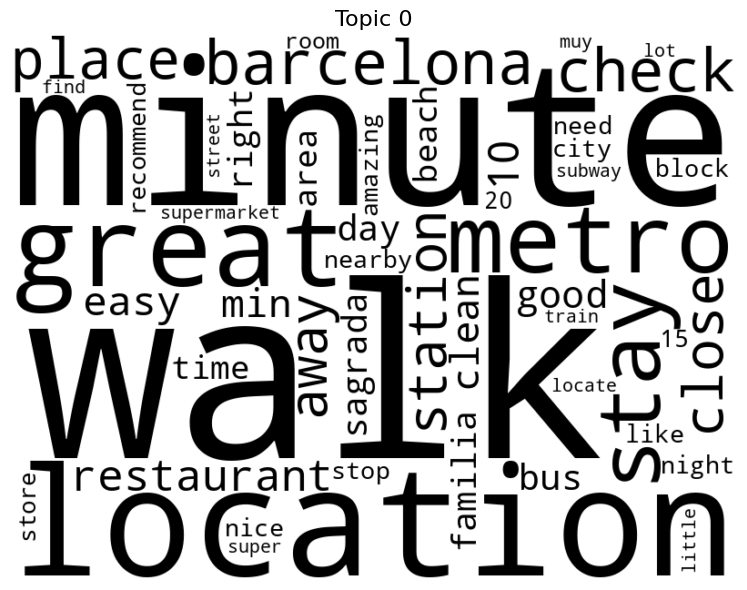

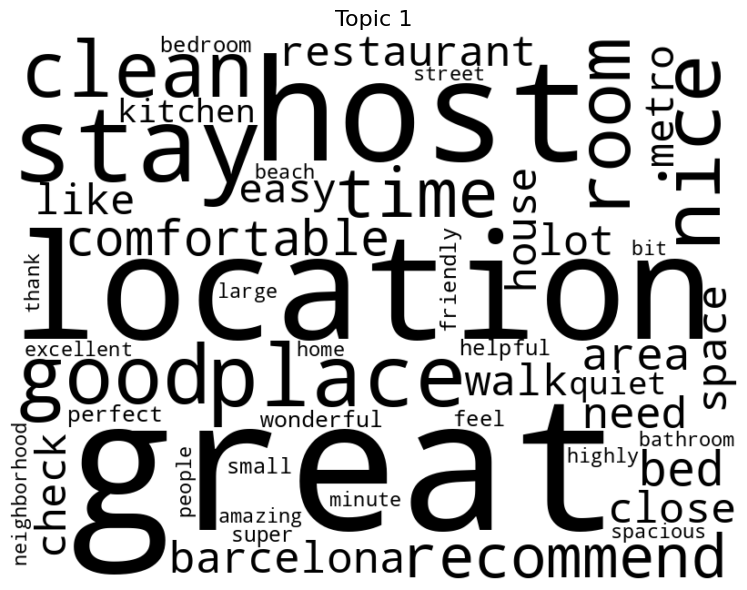

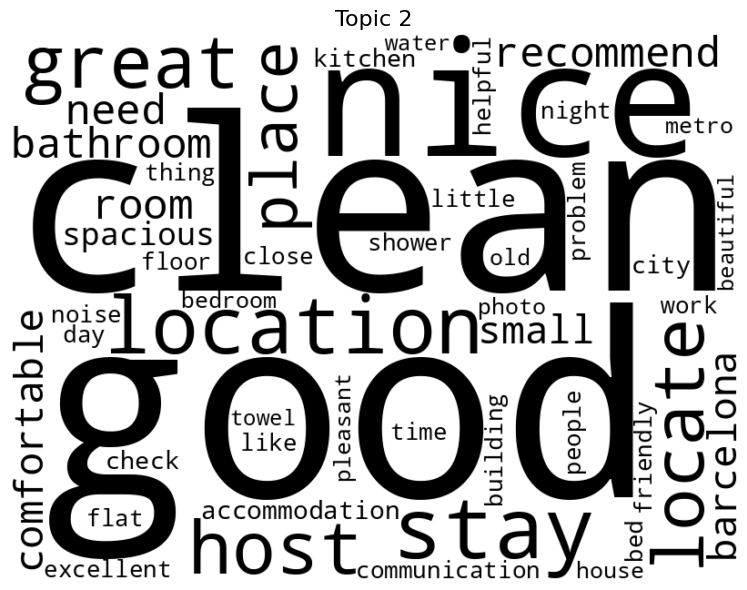

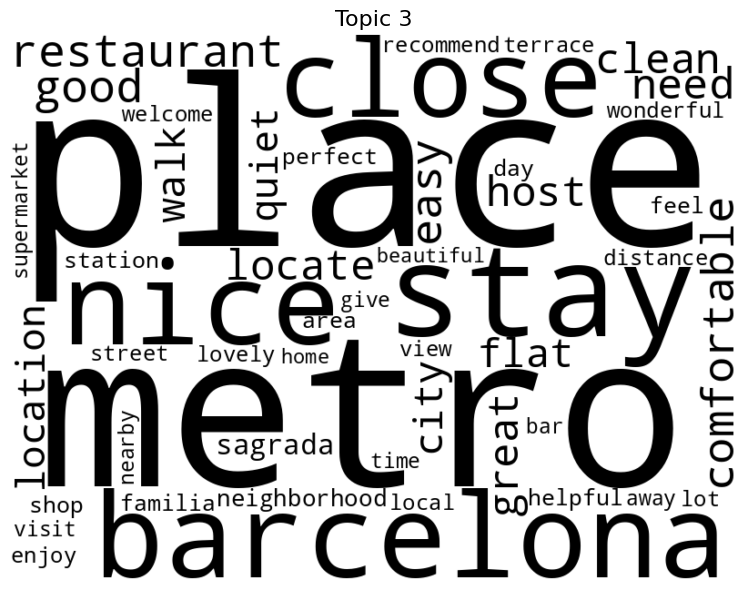

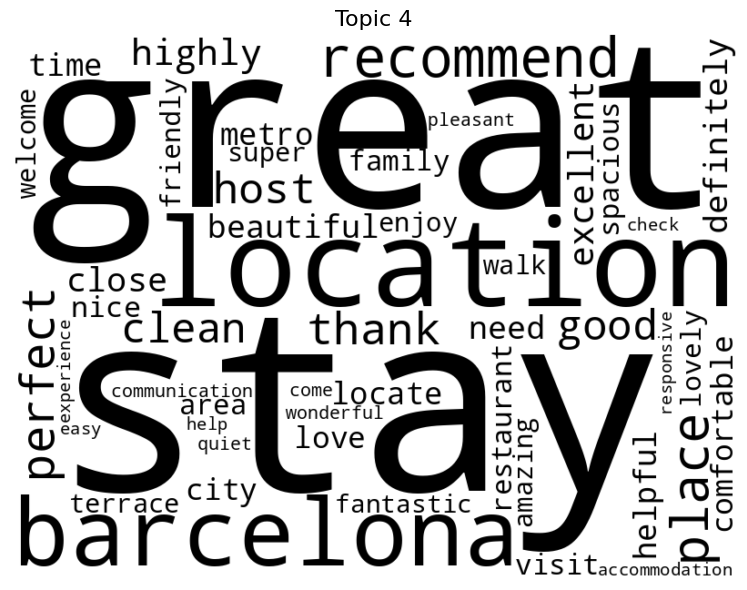

In [27]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Topic Wordclouds

topics_full = lda_model.show_topics(num_topics=-1, num_words=50, formatted=False)

for topic_num, topic_words in topics_full:
    word_freq = dict(topic_words)
    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        color_func=lambda *args, **kwargs: "black",
        min_font_size=10
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Topic {topic_num}', fontsize=16)
    plt.tight_layout()
    plt.show()

Here are the descriptive names based on their dominant words:

*   **Topic 1: Walkability, Transit & Location Convenience** (walk, minute, location, metro, close)
*   **Topic 2: Great Host & Room Experience** (great, location, host, stay, clean, room)
*   **Topic 3: Cleanliness & General Satisfaction** (good, clean, nice, stay, location)
*   **Topic 4: Neighborhood Amenities & Comfort** (place, metro, barcelona, restaurant, comfortable)
*   **Topic 5: Highly Recommended & Perfect Stays** (stay, great, location, recommend, perfect, thank)

The LDA results show that guest reviews are concentrated around a few recurring dimensions of the stay experience. Location-related terms such as `location`, `metro`, `walk`, and `minute` appear across several topics, which indicates that accessibility and neighborhood convenience are central to how guests evaluate Airbnb listings in Barcelona.

A second strong pattern is service and accommodation quality. Words such as `host`, `clean`, `room`, and `comfortable` highlight that host interaction, cleanliness, and in-room comfort are discussed together and jointly shape perceived quality. This suggests that operational improvements in communication and property upkeep can influence guest satisfaction at the same time.

Finally, the topic with terms like `recommend`, `perfect`, and `thank` captures clear signals of positive post-stay sentiment and overall approval. Taken together, the five-topic structure indicates that high satisfaction is multi-factorial: good location, clean and comfortable spaces, and responsive hosting consistently appear as the main drivers of favorable review language.


=== Percentage of Reviews per Dominant Topic ===

  Topic 0: Walkability, Transit & Location Convenience: 11.92%
  Topic 1: Great Host & Room Experience: 18.4%
  Topic 2: Cleanliness & General Satisfaction: 14.6%
  Topic 3: Neighborhood Amenities & Comfort: 17.41%
  Topic 4: Highly Recommended & Perfect Stays: 37.67%


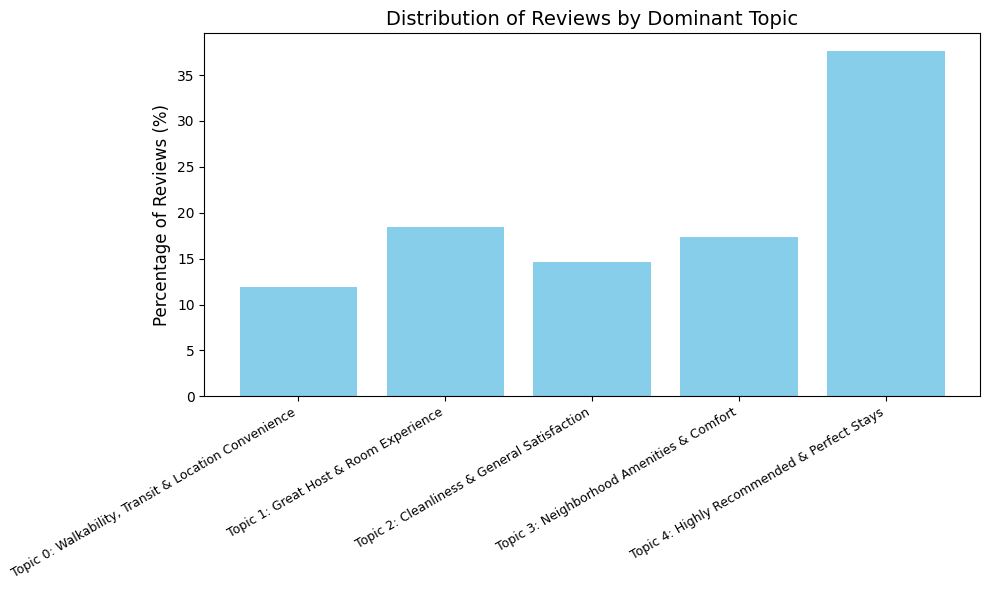

In [29]:
# Percentage of reviews per dominant topic
corpus_data['dominant_topic'] = corpus_data[[f'topic_{i}' for i in range(num_topics)]].idxmax(axis=1)

topic_counts = corpus_data['dominant_topic'].value_counts().sort_index()
topic_pcts = (topic_counts / len(corpus_data) * 100).round(2)

topic_names = {
    'topic_0': 'Topic 0: Walkability, Transit & Location Convenience',
    'topic_1': 'Topic 1: Great Host & Room Experience',
    'topic_2': 'Topic 2: Cleanliness & General Satisfaction',
    'topic_3': 'Topic 3: Neighborhood Amenities & Comfort',
    'topic_4': 'Topic 4: Highly Recommended & Perfect Stays'
}

print("=== Percentage of Reviews per Dominant Topic ===\n")
for topic, pct in topic_pcts.items():
    print(f"  {topic_names[topic]}: {pct}%")

# Plot
plt.figure(figsize=(10, 6))
plt.bar([topic_names[t] for t in topic_pcts.index], topic_pcts.values, color='skyblue')
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.title('Distribution of Reviews by Dominant Topic', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### Supervised Classification

To further analyze the information contained in Airbnb reviews, we implement a supervised machine learning approach to predict whether a review reflects a positive or negative guest experience. Since the dataset does not include explicit sentiment labels, we first generate a binary target variable using sentiment analysis. Each review is assigned a polarity score, which is then used to classify the review as either positive or negative.

Next, the textual reviews are transformed into numerical features using TF–IDF vectorization, which represents each review as a weighted combination of words based on their importance in the corpus. The dataset is then split into training and testing sets in order to evaluate the model's ability to generalize to unseen data.

Finally, a classification model is trained using the TF–IDF features to predict the sentiment label of each review. The model’s performance is evaluated using standard metrics such as accuracy and confusion matrices, and the most informative words identified by the model are analyzed to better understand which linguistic features are associated with positive and negative Airbnb experiences.


In [28]:
# We define our binary target label by applying a sentiment analysis methodology
from textblob import TextBlob

preprocessed_comments['sentiment'] = data_train.loc[
    preprocessed_comments.index,
    'Reviews_Translation'
].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

preprocessed_comments['label'] = preprocessed_comments['sentiment'].apply(
    lambda x: 1 if x > 0 else 0
)


KeyError: '[391, 815, 1037, 1055, 1953, 2462, 2634, 2680, 3291, 3434, 3496, 4148, 4258, 4473, 4724, 4797, 4846, 5231, 5420, 5919, 6230, 6327, 7011, 7639, 7650, 7991, 7993, 8435, 8606, 8776, 10735, 11788, 12764, 13332, 13741, 13823, 14398, 15159, 16778, 17133, 17229, 17465, 17712, 18380, 18630, 19048, 19756, 20288, 21008, 21516, 21766, 22000, 22106, 24318, 24398, 24617, 24630, 24854, 25052, 25309, 25702, 26147, 26278, 26396, 26748, 26754, 27310, 27364, 27982, 29638, 29670, 31133, 31907, 31932, 32502, 32528, 32545, 33827, 35139, 35162, 35165, 35638, 35734, 36089, 36176, 36560, 37060, 38313, 39284, 39593, 39656, 39996, 40300, 40653, 43543, 44487, 45763, 47066, 47199, 50141, 50812, 50826, 51381, 51725, 52504, 53243, 55199, 55623, 56363, 57211, 57340, 57467, 58419, 58659, 58836, 59804, 61609, 62729, 62885, 63854, 64128, 64669, 64933, 65123, 65356, 65459, 65472, 67002, 67085, 67227, 68026, 68051, 69098, 69535, 69724, 70977, 71694, 72319, 73494, 74163, 74375, 74401, 75053, 75352, 75392, 75399

In [ ]:

binary_sentiment_review = preprocessed_comments['label']
binary_sentiment_review.value_counts()

# Align y with the same rows used for TF-IDF
y = preprocessed_comments.loc[valid_index, 'label']
print("y shape:", y.shape)


In [ ]:

# Define variables for the model
X = X_tfidf


In [ ]:
#3. We use the tf-idf output that we already got
X_tfidf.shape

In [ ]:
y.shape

In [ ]:
#4. We do some train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, #output from the tf_idf
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#5. We train the model (we can use more apart from Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced' #because our dataset is umbalanced
)

model.fit(X_train, y_train)

In [ ]:
#6. We predict with our trained model
y_pred = model.predict(X_test)

In [ ]:
#7. We evaluate our model's prediction
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# Evaluation of the results

In [ ]:
#Most important words (according to the model)
feature_names = tfidf_vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

In [ ]:
#Most important positive words
top_positive = coefficients.argsort()[-20:]

[feature_names[i] for i in top_positive]

In [ ]:
#Most important negative words
top_negative = coefficients.argsort()[:20]

[feature_names[i] for i in top_negative]